# Belief-Aware LLMs — Evaluation Analysis
This notebook loads `eval_results.csv`, keeps the raw frame available as `df_raw`, and builds a cleaned analysis frame plus convenience slices for runs, models, and metrics.

In [3]:
from collections import defaultdict
import pandas as pd


CONDITION_COLUMNS = ['With_Store', 'Store_History', 'No_Store']


def load_eval_results(path='eval_results.csv', keep_runs=None, dedupe=True):
    df_raw = pd.read_csv(path)
    df_raw.columns = [c.strip() for c in df_raw.columns]

    alt_map = {
        'With_Store': ['With Store', 'with_store'],
        'Store_History': ['Store History', 'store_history'],
        'No_Store': ['No Store', 'no_store'],
    }
    rename_map = {}
    for canonical, aliases in alt_map.items():
        if canonical not in df_raw.columns:
            for alias in aliases:
                if alias in df_raw.columns:
                    rename_map[alias] = canonical
                    break
    if rename_map:
        df_raw = df_raw.rename(columns=rename_map)

    df = df_raw.copy()
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    if 'Runs' in df.columns:
        df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')
    if 'Temp' in df.columns:
        df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

    if keep_runs is not None and 'Runs' in df.columns:
        df = df[df['Runs'] == keep_runs].copy()

    if dedupe and {'Timestamp', 'Model', 'Domain', 'Prompt_Ver', 'Temp'}.issubset(df.columns):
        dedup_subset = ['Timestamp', 'Model', 'Domain', 'Prompt_Ver', 'Temp']
        if 'Summary_Metric' in df.columns:
            dedup_subset.append('Summary_Metric')
        df = df.sort_values('Timestamp').drop_duplicates(subset=dedup_subset, keep='last')

    condition_cols = [column for column in CONDITION_COLUMNS if column in df.columns]
    if condition_cols:
        id_vars = [column for column in df.columns if column not in condition_cols]
        df_melted = df.melt(
            id_vars=id_vars,
            value_vars=condition_cols,
            var_name='Condition',
            value_name='Value',
        ).dropna(subset=['Value']).copy()
        df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')
        df_melted = df_melted.dropna(subset=['Value']).copy()
    else:
        df_melted = df.copy()
        if 'Value' not in df_melted.columns:
            numeric_candidates = df_melted.select_dtypes(include='number').columns.tolist()
            if numeric_candidates:
                df_melted = df_melted.rename(columns={numeric_candidates[0]: 'Value'})
        if 'Condition' not in df_melted.columns:
            df_melted['Condition'] = 'value'

    if 'Summary_Metric' in df_melted.columns:
        df_acc = df_melted[df_melted['Summary_Metric'].eq('Average_Accuracy')].copy()
    else:
        df_acc = df_melted.copy()

    metric_names = df_melted['Summary_Metric'].dropna().astype(str).unique().tolist() if 'Summary_Metric' in df_melted.columns else []
    calib_metrics = [metric for metric in metric_names if 'calib' in metric.lower() or 'confidence' in metric.lower()]
    evidence_metrics = [metric for metric in metric_names if 'evidence' in metric.lower() or 'support' in metric.lower()]
    dfs_calib = {metric: df_melted[df_melted['Summary_Metric'] == metric].copy() for metric in calib_metrics}
    dfs_evidence = {metric: df_melted[df_melted['Summary_Metric'] == metric].copy() for metric in evidence_metrics}

    dfs_runs = {int(run): group.copy() for run, group in df_melted.groupby('Runs')} if 'Runs' in df_melted.columns else {}
    dfs_by_metric = {metric: group.copy() for metric, group in df_melted.groupby('Summary_Metric')} if 'Summary_Metric' in df_melted.columns else {}
    dfs_by_model = {model: group.copy() for model, group in df_melted.groupby('Model')} if 'Model' in df_melted.columns else {}

    return df_raw, df, df_acc, df_melted, dfs_calib, dfs_evidence, dfs_runs, dfs_by_metric, dfs_by_model

KEEP_RUNS = None
(df_raw, df, df_acc, df_melted, dfs_calib, dfs_evidence, dfs_runs, dfs_by_metric, dfs_by_model) = load_eval_results(keep_runs=KEEP_RUNS)

print('Raw rows:', len(df_raw))
print('Filtered rows:', len(df))
print('Melted rows:', len(df_melted))
print('Models:', df['Model'].nunique() if 'Model' in df.columns else 0)
print('Runs:', sorted(dfs_runs.keys()))

Raw rows: 1764
Filtered rows: 1685
Melted rows: 2536
Models: 5
Runs: [1, 2, 10]


### Quick usage examples
Use the raw frame for inspection, the cleaned frame for analysis, and `dfs_by_model` or `dfs_runs` for slicing by model or run count. The timestamp filter below shows how to pull rows for today.

In [4]:
# Quick usage examples
print('Raw rows:', len(df_raw))
print('Wide rows:', len(df))
print('Long rows:', len(df_melted))
print('Conditions:', sorted(df_melted['Condition'].dropna().astype(str).unique().tolist()) if 'Condition' in df_melted.columns else [])
print('Models:', sorted(df['Model'].dropna().astype(str).unique())[:10] if 'Model' in df.columns else [])
print('Runs:', sorted(df['Runs'].dropna().astype(int).unique()) if 'Runs' in df.columns else [])

if 'gemma4:e2b' in dfs_by_model:
    display(dfs_by_model['gemma4:e2b'].head())
elif dfs_by_model:
    first_model = next(iter(dfs_by_model))
    display(dfs_by_model[first_model].head())

if 'Timestamp' in df.columns:
    today = pd.Timestamp.today().normalize()
    today_rows = df[df['Timestamp'].dt.normalize() == today]
    display(today_rows[['Timestamp', 'Model', 'Domain', 'Runs', 'Summary_Metric']].head(20))

Raw rows: 1764
Wide rows: 1685
Long rows: 2536
Conditions: ['No_Store', 'With_Store']
Models: ['gemma3:1b', 'gemma4:e2b', 'hoangquan456/qwen3-nothink:4b', 'llama3.2:1b', 'ministral-3:3b']
Runs: [np.int64(1), np.int64(2), np.int64(10)]


,Timestamp,Domain,Model,Temp,Prompt_Ver,Runs,Summary_Metric,Class_Label,Condition,Value
324,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_Cited_Keys,NaN,With_Store,4.9000
325,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_F1,NaN,With_Store,0.4043
326,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_Canonical_Keys,NaN,With_Store,12.3000
327,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_Precision,NaN,With_Store,0.7112
328,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Calibration_LogLoss,NaN,With_Store,0.0000


,Timestamp,Model,Domain,Runs,Summary_Metric


### Metrics comparison
This cell compares all models for rows with `Runs == 1` on today's date and draws a heatmap from the first numeric metric column it finds.

In [5]:
# Metrics comparison for Runs == 1 on today's date
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_DATE = pd.Timestamp.today().normalize()

src = df.copy()
if 'Timestamp' in src.columns:
    src['Timestamp'] = pd.to_datetime(src['Timestamp'], errors='coerce')
if 'Runs' in src.columns:
    src['Runs'] = pd.to_numeric(src['Runs'], errors='coerce')

runs_today = src[(src['Runs'] == 1) & (src['Timestamp'].dt.normalize() == TARGET_DATE)].copy()
print(f'Results for {TARGET_DATE.date()} (Runs == 1):')

if runs_today.empty:
    print('No rows found for Runs == 1 on the selected date.')
    display(src.sort_values('Timestamp', ascending=False).head(25))
else:
    condition_cols = [column for column in ['With_Store', 'Store_History', 'No_Store'] if column in runs_today.columns]
    metric_col = None
    if 'Value' in runs_today.columns:
        metric_col = 'Value'
    elif condition_cols:
        metric_col = condition_cols[0]
    else:
        numeric_cols = runs_today.select_dtypes(include='number').columns.tolist()
        numeric_cols = [column for column in numeric_cols if column not in ['Runs', 'Temp']]
        if numeric_cols:
            metric_col = numeric_cols[0]

    if metric_col is None:
        raise RuntimeError('No numeric metric column found for comparison.')

    pivot = runs_today.pivot_table(index='Summary_Metric', columns='Model', values=metric_col, aggfunc='first').sort_index()
    display(pivot)

    if not pivot.empty:
        plt.figure(figsize=(max(8, pivot.shape[1] * 0.8), max(3, pivot.shape[0] * 0.45)))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='vlag', center=0, cbar_kws={'label': metric_col})
        plt.title(f'Runs == 1 on {TARGET_DATE.date()}')
        plt.xlabel('Model')
        plt.ylabel('Metric')
        plt.tight_layout()
        plt.show()

Results for 2026-05-10 (Runs == 1):
No rows found for Runs == 1 on the selected date.


,Timestamp,Domain,Model,Temp,Prompt_Ver,Runs,Summary_Metric,With_Store,Store_History,No_Store,Class_Label
1763,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,Average_SBIR_SpuriousInjection,0.2387,NaN,NaN,NaN
1752,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,WCT_WallClock_PerTurn_Seconds,35.6652,NaN,NaN,NaN
1757,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,Average_Evidence_Precision,0.6417,NaN,NaN,NaN
1756,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,EMD_NoStore_bracketed_exact,1.0000,NaN,NaN,NaN
1758,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,Average_Evidence_Recall,0.7167,NaN,NaN,NaN
1755,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,EMD_WithStore_bracketed_exact,1.0000,NaN,NaN,NaN
1760,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,Average_Evidence_Cited_Keys,4.4000,NaN,NaN,NaN
1759,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,Average_Evidence_F1,0.6546,NaN,NaN,NaN
1754,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,TPCA_Words_Wrong,6.0000,NaN,250.0,NaN
1762,2026-05-09 20:19:16,crime_scene_absurd_temporal,gemma4:e2b,0.0,v16,1,Average_BCR_BeliefCoverage,1.0000,NaN,NaN,NaN


## 1. Stability & Noise Reduction Analysis (AFR & DS)
**Claim:** The belief store reduces sampling noise and makes the LLM more deterministic.
*   **Plot:** A comparative bar chart showing the **Answer Flip Rate (AFR)** and **Determinism Score (DS)** for `With_Store` vs. `No_Store` across all models (filtered for `Runs > 1`).
*   **Value:** Proves that even when models hallucinate, the belief store forces them to be internally consistent.

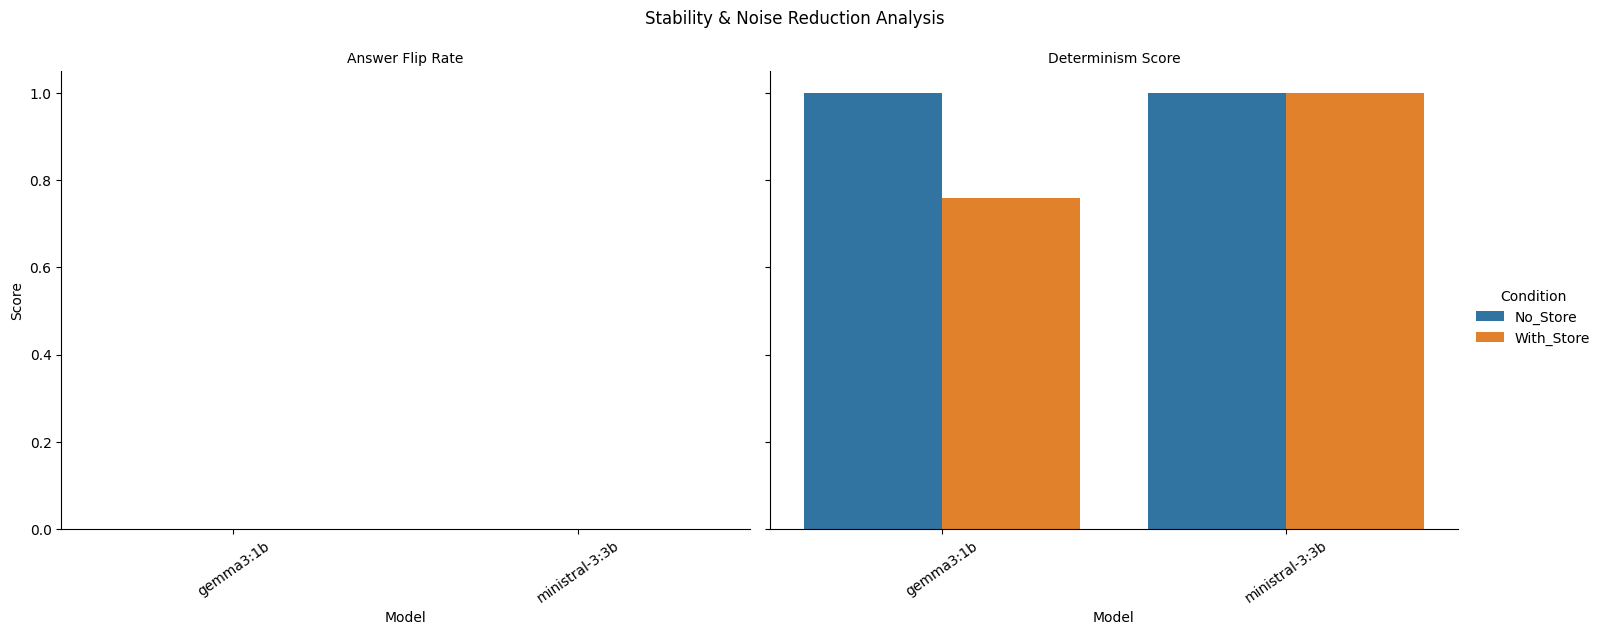

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

metric_labels = {
    'AFR_Answer_Flip_Rate': 'Answer Flip Rate',
    'DS_Determinism_Score': 'Determinism Score',
}

stability_df = df_melted[
    (df_melted['Runs'] > 1)
    & df_melted['Summary_Metric'].isin(metric_labels)
    & df_melted['Condition'].isin(['With_Store', 'No_Store'])
].copy()

if stability_df.empty:
    print('Not enough data with Runs > 1 for AFR and DS metrics.')
else:
    stability_df['Metric_Label'] = stability_df['Summary_Metric'].map(metric_labels)
    summary = stability_df.groupby(['Metric_Label', 'Model', 'Condition'], as_index=False)['Value'].mean()
    g = sns.catplot(
        data=summary,
        kind='bar',
        x='Model',
        y='Value',
        hue='Condition',
        col='Metric_Label',
        height=5.5,
        aspect=1.35,
    )
    g.set_axis_labels('Model', 'Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('Stability & Noise Reduction Analysis', y=1.05)
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=35)
    plt.show()

## 2. Prior Suppression (The `absurd` Domains)
**Claim:** The belief store successfully overrides the LLM's parametric priors.
*   **Plot:** A grouped bar chart comparing `Average_Accuracy` on all `_absurd` scenarios.
*   **Value:** The delta between `With_Store` and `No_Store` here is the defining proof of Belief-Awareness.

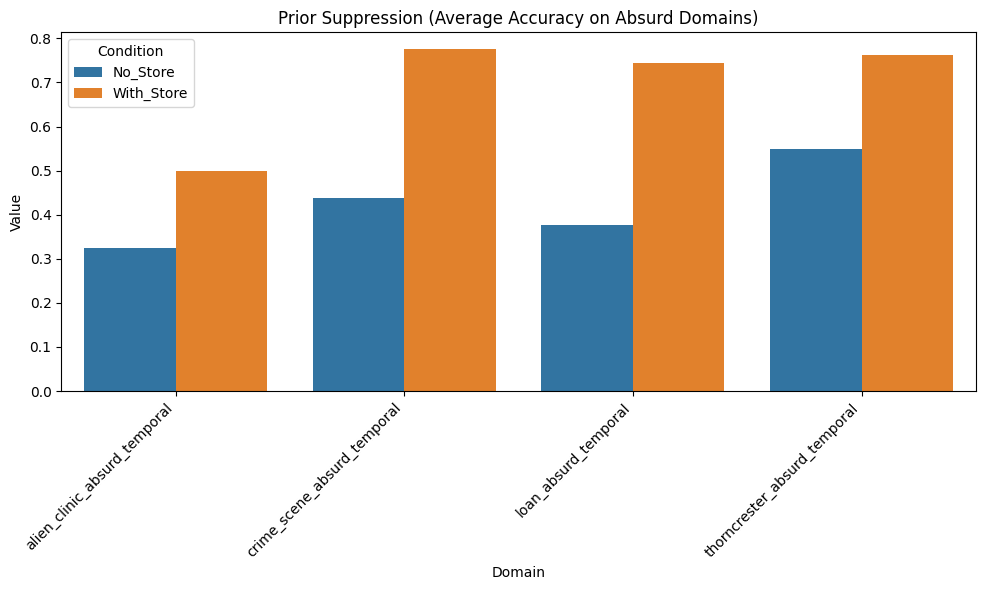

In [7]:
absurd_df = df_melted[
    df_melted['Domain'].str.contains('_absurd', na=False)
    & df_melted['Summary_Metric'].eq('Average_Accuracy')
    & df_melted['Condition'].isin(['With_Store', 'No_Store'])
].copy()

if absurd_df.empty:
    print('No data found for absurd domains.')
else:
    summary = absurd_df.groupby(['Domain', 'Condition'], as_index=False)['Value'].mean()
    domain_order = sorted(summary['Domain'].dropna().astype(str).unique().tolist())

    plt.figure(figsize=(max(10, len(domain_order) * 1.1), 6))
    sns.barplot(data=summary, x='Domain', y='Value', hue='Condition', order=domain_order)
    plt.title('Prior Suppression (Average Accuracy on Absurd Domains)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3. Context Stability (The `belief_maintenance` Domains)
**Claim:** The Belief Engine (HopWalker) shields the LLM from accumulating distractor facts.
*   **Plot:** A heatmap or trendline showing accuracy on `belief_maintenance` domains across the different models.
*   **Value:** Proves that the system doesn't degrade as the conversational context window fills up with irrelevant facts.

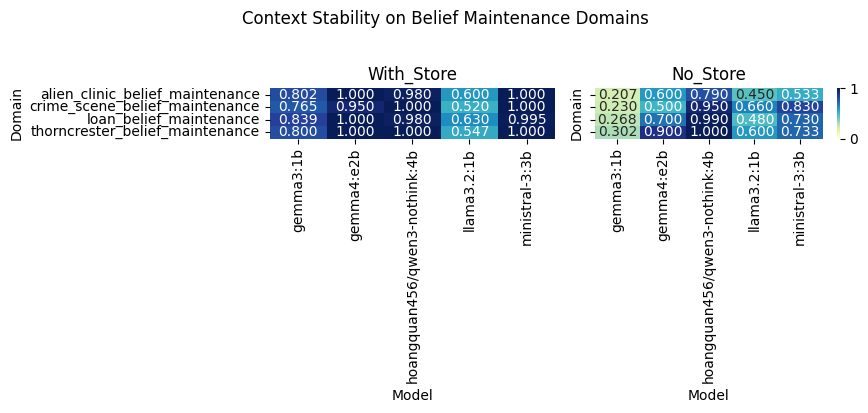

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

context_df = df_melted[
    df_melted['Domain'].str.contains('belief_maintenance', na=False)
    & df_melted['Summary_Metric'].eq('Average_Accuracy')
    & df_melted['Condition'].isin(['With_Store', 'No_Store'])
].copy()

if context_df.empty:
    print('No belief_maintenance accuracy data found.')
else:
    summary = context_df.groupby(['Domain', 'Model', 'Condition'], as_index=False)['Value'].mean()
    domain_order = sorted(summary['Domain'].dropna().astype(str).unique().tolist())
    condition_order = [condition for condition in ['With_Store', 'No_Store'] if condition in summary['Condition'].unique()]

    fig, axes = plt.subplots(
        1,
        len(condition_order),
        figsize=(max(8, 4.5 * len(condition_order)), max(4, 0.55 * len(domain_order))),
        sharey=True,
    )
    if len(condition_order) == 1:
        axes = [axes]

    for index, (ax, condition) in enumerate(zip(axes, condition_order)):
        pivot = (
            summary[summary['Condition'] == condition]
            .pivot(index='Domain', columns='Model', values='Value')
            .reindex(domain_order)
        )
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.3f',
            cmap='YlGnBu',
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=index == len(condition_order) - 1,
        )
        ax.set_title(condition)
        ax.set_xlabel('Model')
        ax.set_ylabel('Domain')

    fig.suptitle('Context Stability on Belief Maintenance Domains', y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Efficiency Analysis (TPCA & WCT)
**Claim:** The belief store creates more concise, directed reasoning.
*   **Plot:** Scatter plot of **Tokens Per Correct Answer (TPCA)** vs. Accuracy, colored by Model and Store Condition.
*   **Value:** Visually demonstrates that `With_Store` leads to shorter, more precise answers compared to `No_Store` (which likely rambles or hallucinates longer responses).

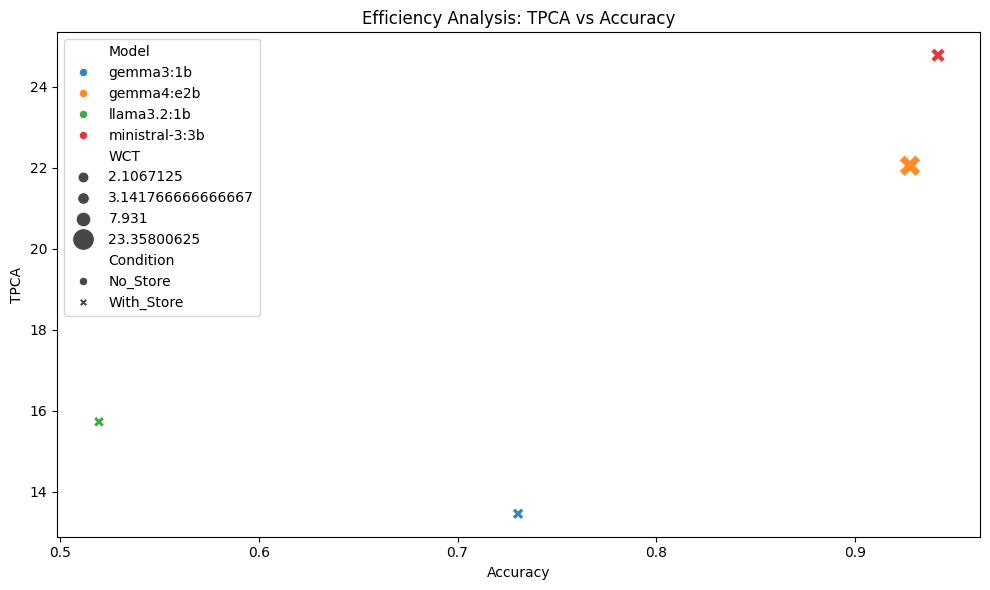

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_df = (
    df_melted[df_melted['Summary_Metric'].eq('Average_Accuracy')]
    .groupby(['Model', 'Condition'], as_index=False)['Value']
    .mean()
    .rename(columns={'Value': 'Accuracy'})
)

tpca_df = (
    df_melted[df_melted['Summary_Metric'].eq('TPCA_Words_Correct')]
    .groupby(['Model', 'Condition'], as_index=False)['Value']
    .mean()
    .rename(columns={'Value': 'TPCA'})
)

wct_df = (
    df_melted[df_melted['Summary_Metric'].eq('WCT_WallClock_PerTurn_Seconds')]
    .groupby(['Model', 'Condition'], as_index=False)['Value']
    .mean()
    .rename(columns={'Value': 'WCT'})
)

eff_df = accuracy_df.merge(tpca_df, on=['Model', 'Condition'], how='inner').merge(wct_df, on=['Model', 'Condition'], how='left')

if eff_df.empty:
    print('Not enough data for TPCA vs Accuracy scatter plot.')
else:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=eff_df,
        x='Accuracy',
        y='TPCA',
        hue='Model',
        style='Condition',
        size='WCT',
        sizes=(60, 240),
        alpha=0.9,
    )
    plt.title('Efficiency Analysis: TPCA vs Accuracy')
    plt.tight_layout()
    plt.show()

## 5. Retrieval Fidelity Check (BCR)
**Claim:** Upstream graph extraction never dropped required facts.
*   **Table:** A simple validation table confirming that **Belief Coverage Rate (BCR)** is 1.0 across all runs.

In [10]:
from IPython.display import display

bcr_df = df_melted[df_melted['Summary_Metric'].eq('Average_BCR_BeliefCoverage')].copy()

if bcr_df.empty:
    print('No BCR data found.')
else:
    bcr_summary = (
        bcr_df.groupby(['Model', 'Condition'], as_index=False)['Value']
        .agg(['mean', 'min', 'max', 'count'])
        .reset_index()
    )
    print('Belief Coverage Rate (BCR) Summary:')
    display(bcr_summary)

    if (bcr_df['Value'] == 1.0).all():
        print('\nSuccess: BCR is 1.0 across all runs.')
    else:
        print('\nWarning: BCR is not 1.0 for all runs.')
        display(bcr_df[bcr_df['Value'] != 1.0][['Timestamp', 'Domain', 'Model', 'Condition', 'Value']].head(20))

Belief Coverage Rate (BCR) Summary:


,index,Model,Condition,mean,min,max,count
0,0,gemma3:1b,With_Store,1.0,1.0,1.0,21
1,1,gemma4:e2b,With_Store,1.0,1.0,1.0,16
2,2,llama3.2:1b,With_Store,1.0,1.0,1.0,16
3,3,ministral-3:3b,With_Store,1.0,1.0,1.0,17



Success: BCR is 1.0 across all runs.
